# NB08 — Feature Engineering (Multi-Session, User 2)

Replaces NB02 for the user2 multi-session dataset (13 sessions, 58,512 rows).  
Key differences from user1 engineering:
- EEG band power columns are all-zero → dropped entirely
- 22 non-zero features instead of 246
- Binary action space (Hold=0, Raise=1) — Lower never observed
- Per-session baseline normalisation (each session's ss0 is the reference)
- 5 calibration groups from (TangentCoefficient, TranslationCoefficient) pairs
- Exclude session_2 (77.8% GoodSignalQuality) and session_11 (79.3% GQ, std=1.08)
- Flag session_9 (outlier PV mean=−0.314) and session_5/ss4 (3,349-row anomaly)

In [1]:
import numpy as np
import pandas as pd
import json
import warnings
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')

NEROES_PALETTE = {
    'bg':      '#0d1117',
    'surface': '#161b22',
    'cyan':    '#00c8ff',
    'teal':    '#00e5c3',
    'orange':  '#ff6b35',
    'yellow':  '#ffd700',
    'muted':   '#8b949e',
    'white':   '#e6edf3',
}

matplotlib.rcParams.update({
    'figure.facecolor':  NEROES_PALETTE['bg'],
    'axes.facecolor':    NEROES_PALETTE['surface'],
    'axes.edgecolor':    NEROES_PALETTE['muted'],
    'axes.labelcolor':   NEROES_PALETTE['white'],
    'xtick.color':       NEROES_PALETTE['muted'],
    'ytick.color':       NEROES_PALETTE['muted'],
    'text.color':        NEROES_PALETTE['white'],
    'grid.color':        NEROES_PALETTE['muted'],
    'grid.alpha':        0.2,
    'figure.dpi':        120,
})

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR   = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR   = PROJECT_ROOT / 'outputs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')
print(f'  PROJECT_ROOT : {PROJECT_ROOT}')

Setup complete.
  PROJECT_ROOT : /home/bruno1008/neroes/neroes-neurofeedback


## Section 1 — Load Raw User2 Data

In [2]:
raw = pd.read_parquet(PROCESSED_DIR / 'user2_data.parquet')
print(f'Loaded user2_data.parquet: {raw.shape[0]:,} rows × {raw.shape[1]} cols')
print(f'Sessions: {sorted(raw["session_id"].unique())}')
print(f'Subsessions per session:')
for sid in sorted(raw['session_id'].unique(), key=lambda x: int(x.split('_')[1])):
    ss = sorted(raw.loc[raw['session_id']==sid, 'subsession'].unique())
    n  = raw[raw['session_id']==sid].shape[0]
    print(f'  {sid}: subsessions={ss}, n={n:,}')

Loaded user2_data.parquet: 58,512 rows × 158 cols
Sessions: ['session_1', 'session_10', 'session_11', 'session_12', 'session_13', 'session_2', 'session_3', 'session_4', 'session_5', 'session_6', 'session_7', 'session_8', 'session_9']
Subsessions per session:
  session_1: subsessions=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)], n=3,132
  session_2: subsessions=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)], n=3,740
  session_3: subsessions=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)], n=4,364
  session_4: subsessions=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)], n=3,766
  session_5: subsessions=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)], n=

## Section 2 — Session Filtering

**Exclude:** session_2 (77.8% GoodSignalQuality), session_11 (79.3% GQ + PV std=1.08)  
**Flag (keep but mark):** session_9 (outlier PV mean=−0.314), session_5/ss4 (3,349-row anomaly)

In [3]:
EXCLUDE_SESSIONS = ['session_2', 'session_11']
FLAG_SESSIONS    = ['session_9']   # outlier PV mean
FLAG_SS4         = [('session_5', 4)]  # anomalous subsession

df = raw[~raw['session_id'].isin(EXCLUDE_SESSIONS)].copy()
print(f'After excluding {EXCLUDE_SESSIONS}: {df.shape[0]:,} rows')

# is_anomaly flag: session_9 or session_5/ss4
df['is_anomaly'] = False
df.loc[df['session_id'].isin(FLAG_SESSIONS), 'is_anomaly'] = True
for (sid, ss) in FLAG_SS4:
    mask = (df['session_id'] == sid) & (df['subsession'] == ss)
    df.loc[mask, 'is_anomaly'] = True

n_anom = df['is_anomaly'].sum()
print(f'Anomaly-flagged rows: {n_anom:,} ({100*n_anom/len(df):.1f}%)')
print(f'Remaining sessions: {sorted(df["session_id"].unique())}')

After excluding ['session_2', 'session_11']: 50,194 rows
Anomaly-flagged rows: 7,480 (14.9%)
Remaining sessions: ['session_1', 'session_10', 'session_12', 'session_13', 'session_3', 'session_4', 'session_5', 'session_6', 'session_7', 'session_8', 'session_9']


## Section 3 — Drop EEG Band Power Columns

All EEG spectral band columns are zero in user2 game sessions (verified in NB07).  
Drop them to avoid adding noise features.

In [4]:
BANDS      = ['Alpha', 'Gamma', 'HighBeta', 'LowBeta', 'Theta']
ELECTRODES = ['AF3','AF4','C3','C4','F3','F4','F7','F8','FC5','FC6',
              'Fp1','Fp2','O1','O2','Oz','P7','P8','Pz','T7','T8']

eeg_cols = [f'{e}{b}' for e in ELECTRODES for b in BANDS if f'{e}{b}' in df.columns]
print(f'EEG band columns found: {len(eeg_cols)}')

# Verify all-zero before dropping
game_df = df[df['subsession'] > 0]
nonzero_eeg = [c for c in eeg_cols if game_df[c].abs().sum() > 0]
print(f'Non-zero EEG columns in game subsessions: {len(nonzero_eeg)}')
if nonzero_eeg:
    print(f'  Non-zero columns: {nonzero_eeg[:10]}')

df = df.drop(columns=eeg_cols)
print(f'After dropping EEG columns: {df.shape[1]} columns remaining')

EEG band columns found: 100
Non-zero EEG columns in game subsessions: 40
  Non-zero columns: ['C3Alpha', 'C3Gamma', 'C3HighBeta', 'C3LowBeta', 'C3Theta', 'C4Alpha', 'C4Gamma', 'C4HighBeta', 'C4LowBeta', 'C4Theta']
After dropping EEG columns: 59 columns remaining


## Section 4 — Calibration Group Encoding

5 unique (TangentCoefficient, TranslationCoefficient) pairs observed across sessions.  
These define calibration groups and must be treated as categorical state.

In [5]:
# Identify calibration groups per subsession-start snapshot
calib_cols = ['TangentCoefficient', 'TranslationCoefficient']
pairs = df.groupby('session_id')[calib_cols].first().round(4)
print('Calibration pairs per session:')
print(pairs.to_string())

# Round to 3 decimal places to ensure consistent grouping
df['TC_round']  = df['TangentCoefficient'].round(3)
df['TrC_round'] = df['TranslationCoefficient'].round(3)
df['calib_pair'] = list(zip(df['TC_round'].values, df['TrC_round'].values))

unique_pairs = sorted(df['calib_pair'].unique())
pair_to_idx  = {p: i for i, p in enumerate(unique_pairs)}
df['calib_group'] = df['calib_pair'].map(pair_to_idx)

print(f'\nCalibration groups identified: {len(unique_pairs)}')
for p, idx in pair_to_idx.items():
    n = (df['calib_group'] == idx).sum()
    print(f'  Group {idx}: TC={p[0]:.3f}, TrC={p[1]:.3f}  →  {n:,} rows')

# One-hot encode calibration group
calib_ohe = pd.get_dummies(df['calib_group'], prefix='calib_g').astype(np.float32)
df = pd.concat([df, calib_ohe], axis=1)
calib_ohe_cols = list(calib_ohe.columns)
print(f'\nOne-hot encoded calibration columns: {calib_ohe_cols}')

Calibration pairs per session:
            TangentCoefficient  TranslationCoefficient
session_id                                            
session_1                  0.0                     0.0
session_10                 0.0                     0.0
session_12                 0.0                     0.0
session_13                 0.0                     0.0
session_3                  0.0                     0.0
session_4                  0.0                     0.0
session_5                  0.0                     0.0
session_6                  0.0                     0.0
session_7                  0.0                     0.0
session_8                  0.0                     0.0
session_9                  0.0                     0.0

Calibration groups identified: 6
  Group 0: TC=0.000, TrC=0.000  →  5,332 rows
  Group 1: TC=4.204, TrC=0.043  →  10,511 rows
  Group 2: TC=4.205, TrC=-0.043  →  19,590 rows
  Group 3: TC=4.239, TrC=0.000  →  5,392 rows
  Group 4: TC=4.300, TrC=0.094  →

## Section 5 — Per-Session Baseline Normalisation

For each session, compute mean and std from subsession 0 (ss0 = resting baseline).  
Apply z-score normalisation to game subsession rows using ss0 statistics.

In [6]:
NORM_COLS = [
    'Baseline', 'MaxBaseline', 'MiddleBaseline', 'MinBaseline',
    'Percentile', 'MaxPercentile', 'MiddlePercentile', 'MinPercentile',
    'LevelProgress', 'Morale', 'PlayerPositionX', 'PlayerPositionY',
    'ProtocolValue',
]
NORM_COLS = [c for c in NORM_COLS if c in df.columns]

# Signal quality columns — don't normalise, they're ordinal 0-4
SQ_COLS = [c for c in df.columns if 'SignalQuality' in c]
print(f'Signal quality columns (not normalised): {SQ_COLS}')
print(f'Columns to z-score normalise: {NORM_COLS}')

for col in NORM_COLS:
    z_col = f'{col}_z'
    df[z_col] = np.nan
    for sid in df['session_id'].unique():
        sess_mask = df['session_id'] == sid
        ss0_mask  = sess_mask & (df['subsession'] == 0)
        if ss0_mask.sum() == 0:
            print(f'  WARNING: no ss0 for {sid}, using session mean')
            mu  = df.loc[sess_mask, col].mean()
            std = df.loc[sess_mask, col].std()
        else:
            mu  = df.loc[ss0_mask, col].mean()
            std = df.loc[ss0_mask, col].std()
        std = std if std > 1e-6 else 1.0  # prevent division by zero
        df.loc[sess_mask, z_col] = (df.loc[sess_mask, col] - mu) / std

z_cols_created = [f'{c}_z' for c in NORM_COLS]
print(f'\nCreated {len(z_cols_created)} z-score columns:')
print(df[z_cols_created].describe().round(3))

Signal quality columns (not normalised): ['AF3SignalQuality', 'AF4SignalQuality', 'C3SignalQuality', 'C4SignalQuality', 'F3SignalQuality', 'F4SignalQuality', 'F7SignalQuality', 'F8SignalQuality', 'FC5SignalQuality', 'FC6SignalQuality', 'Fp1SignalQuality', 'Fp2SignalQuality', 'GoodSignalQuality', 'O1SignalQuality', 'O2SignalQuality', 'OzSignalQuality', 'P7SignalQuality', 'P8SignalQuality', 'PzSignalQuality', 'T7SignalQuality', 'T8SignalQuality']
Columns to z-score normalise: ['Baseline', 'MaxBaseline', 'MiddleBaseline', 'MinBaseline', 'Percentile', 'MaxPercentile', 'MiddlePercentile', 'MinPercentile', 'LevelProgress', 'Morale', 'PlayerPositionX', 'PlayerPositionY', 'ProtocolValue']

Created 13 z-score columns:
       Baseline_z  MaxBaseline_z  MiddleBaseline_z  MinBaseline_z  \
count   50194.000      50194.000         50194.000      50194.000   
mean       -0.040          0.009            -0.040         -0.096   
std         0.133          0.129             0.133          0.139   
min  

## Section 6 — Lag and Rolling Features

In [7]:
# Sort by session → subsession → sample_idx before computing lags
df = df.sort_values(['session_id', 'subsession', 'sample_idx']).reset_index(drop=True)

pv = df['ProtocolValue']

# ProtocolValue lags (within-session, cross-subsession)
for lag in [1, 2, 5]:
    df[f'pv_lag{lag}'] = df.groupby('session_id')['ProtocolValue'].shift(lag)

# ProtocolValue deltas
df['pv_delta1'] = df.groupby('session_id')['ProtocolValue'].diff(1)
df['pv_delta2'] = df.groupby('session_id')['ProtocolValue'].diff(2)

# ProtocolValue rolling stats
for w in [5, 10, 20]:
    grp = df.groupby('session_id')['ProtocolValue']
    df[f'pv_rmean{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
    df[f'pv_rstd{w}']  = grp.transform(lambda x: x.rolling(w, min_periods=2).std().fillna(0))

# PlayerPositionY lags
for lag in [1, 2]:
    df[f'PlayerPositionY_lag{lag}'] = df.groupby('session_id')['PlayerPositionY'].shift(lag)

# Baseline lag
df['Baseline_lag1'] = df.groupby('session_id')['Baseline'].shift(1)

lag_cols_created = (
    [f'pv_lag{l}' for l in [1,2,5]] +
    ['pv_delta1','pv_delta2'] +
    [f'pv_rmean{w}' for w in [5,10,20]] +
    [f'pv_rstd{w}' for w in [5,10,20]] +
    ['PlayerPositionY_lag1','PlayerPositionY_lag2','Baseline_lag1']
)
print(f'Lag/rolling features created: {len(lag_cols_created)}')
print(lag_cols_created)
print(f'\nNaN counts in lag features (first-row boundary effects):')
print(df[lag_cols_created].isna().sum())

Lag/rolling features created: 14
['pv_lag1', 'pv_lag2', 'pv_lag5', 'pv_delta1', 'pv_delta2', 'pv_rmean5', 'pv_rmean10', 'pv_rmean20', 'pv_rstd5', 'pv_rstd10', 'pv_rstd20', 'PlayerPositionY_lag1', 'PlayerPositionY_lag2', 'Baseline_lag1']

NaN counts in lag features (first-row boundary effects):
pv_lag1                 11
pv_lag2                 22
pv_lag5                 55
pv_delta1               11
pv_delta2               22
pv_rmean5                0
pv_rmean10               0
pv_rmean20               0
pv_rstd5                 0
pv_rstd10                0
pv_rstd20                0
PlayerPositionY_lag1    11
PlayerPositionY_lag2    22
Baseline_lag1           11
dtype: int64


## Section 7 — Context and Position Features

In [8]:
# Session number (1-based integer, for temporal ordering in models)
session_order = sorted(df['session_id'].unique(), key=lambda x: int(x.split('_')[1]))
sess_num_map  = {s: i+1 for i, s in enumerate(session_order)}
df['session_num'] = df['session_id'].map(sess_num_map)

# is_baseline flag
df['is_baseline'] = (df['subsession'] == 0).astype(np.float32)

# subsession_norm: normalise subsession index within session to [0,1]
max_ss = df.groupby('session_id')['subsession'].transform('max').clip(lower=1)
df['subsession_norm'] = df['subsession'] / max_ss

# sample_idx_norm: normalise sample position within (session, subsession) to [0,1]
max_idx = df.groupby(['session_id','subsession'])['sample_idx'].transform('max').clip(lower=1)
df['sample_idx_norm'] = df['sample_idx'] / max_idx

context_cols = ['session_num', 'is_baseline', 'subsession_norm', 'sample_idx_norm', 'is_anomaly']
print('Context feature stats:')
print(df[context_cols].describe().round(3))

Context feature stats:
       session_num  is_baseline  subsession_norm  sample_idx_norm
count    50194.000    50194.000        50194.000        50194.000
mean         6.034        0.106            0.515            0.500
std          2.996        0.308            0.314            0.289
min          1.000        0.000            0.000            0.000
25%          4.000        0.000            0.286            0.250
50%          6.000        0.000            0.444            0.500
75%          9.000        0.000            0.778            0.750
max         11.000        1.000            1.000            1.000


## Section 8 — Binary Action Labels

Action is defined as the inter-subsession change in TangentCoefficient:  
- **Raise (1):** TC increases at subsession boundary  
- **Hold (0):** TC stays the same  
- **Lower:** never observed → excluded from action space

In [9]:
# Compute per-subsession TC value (first row of each subsession)
ss_tc = df.groupby(['session_id','subsession'])['TangentCoefficient'].first().reset_index()
ss_tc = ss_tc.sort_values(['session_id','subsession'])
ss_tc['TC_prev'] = ss_tc.groupby('session_id')['TangentCoefficient'].shift(1)
ss_tc['TC_delta'] = ss_tc['TangentCoefficient'] - ss_tc['TC_prev']

# Action: +1 if TC raised, 0 if held, -1 if lowered
def tc_to_action(delta):
    if pd.isna(delta):
        return np.nan  # first subsession has no previous
    elif delta > 0.001:
        return 1  # Raise
    elif delta < -0.001:
        return -1  # Lower (should not appear)
    else:
        return 0  # Hold

ss_tc['action_raw'] = ss_tc['TC_delta'].apply(tc_to_action)

print('Action distribution across inter-subsession transitions:')
act_counts = ss_tc['action_raw'].value_counts(dropna=True)
print(act_counts)
total_transitions = act_counts.sum()
for a, n in act_counts.items():
    label = {1:'Raise', 0:'Hold', -1:'Lower'}.get(int(a), '?')
    print(f'  {label}: {n}/{total_transitions} = {100*n/total_transitions:.1f}%')

# Merge back to main dataframe
ss_tc_map = ss_tc.set_index(['session_id','subsession'])['action_raw'].to_dict()
df['action'] = df.apply(lambda r: ss_tc_map.get((r['session_id'], r['subsession']), np.nan), axis=1)

# Binary action: remap {0:'Hold', 1:'Raise'} dropping Lower (none expected)
df['action_binary'] = df['action'].map({0: 0, 1: 1, -1: np.nan})
print(f'\nRows with valid binary action label: {df["action_binary"].notna().sum():,}')
print(f'Rows without (first subsession per session): {df["action_binary"].isna().sum():,}')

Action distribution across inter-subsession transitions:
action_raw
0.0    82
1.0    11
Name: count, dtype: int64
  Hold: 82/93 = 88.2%
  Raise: 11/93 = 11.8%

Rows with valid binary action label: 44,862
Rows without (first subsession per session): 5,332


## Section 9 — Reward Signal

Reward = clipped `pv_delta1` (one-step ProtocolValue change).  
Clipped to [−0.5, +0.5] to prevent outlier reward spikes.

Reward statistics (clipped pv_delta1):
count    50183.0000
mean         0.0001
std          0.3760
min         -0.5000
25%         -0.3892
50%          0.0000
75%          0.3904
max          0.5000
Name: reward, dtype: float64


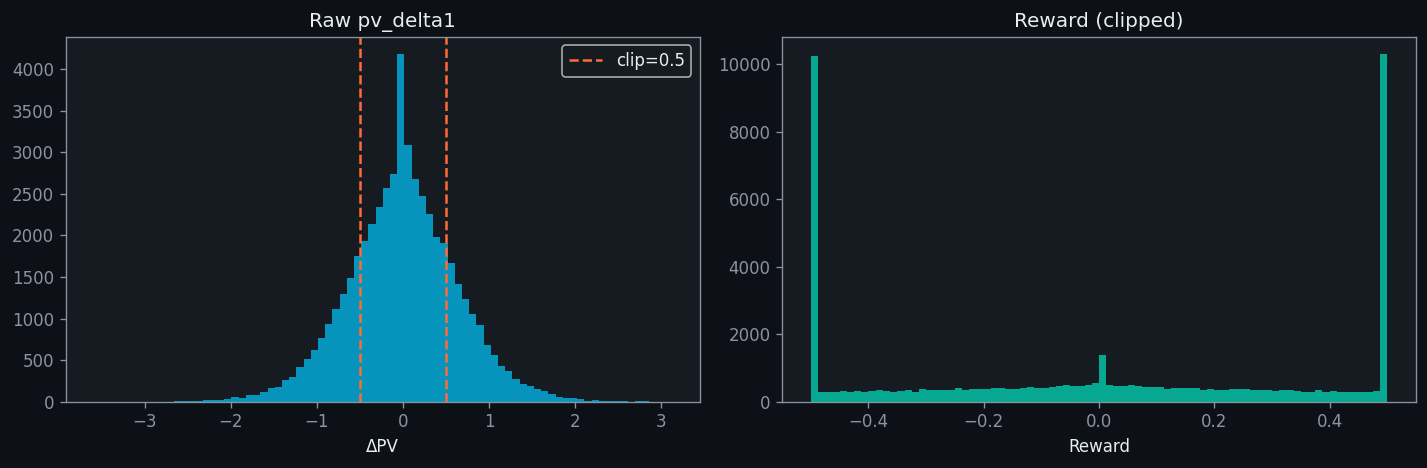

Saved: u2_reward_distribution.png


In [10]:
REWARD_CLIP = 0.5
df['reward'] = df['pv_delta1'].clip(-REWARD_CLIP, REWARD_CLIP)

print('Reward statistics (clipped pv_delta1):')
print(df['reward'].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                          facecolor=NEROES_PALETTE['bg'])
ax1, ax2 = axes

ax1.hist(df['pv_delta1'].dropna(), bins=80, color=NEROES_PALETTE['cyan'], alpha=0.7)
ax1.set_title('Raw pv_delta1', color=NEROES_PALETTE['white'])
ax1.set_xlabel('ΔPV', color=NEROES_PALETTE['white'])
ax1.axvline(-REWARD_CLIP, color=NEROES_PALETTE['orange'], ls='--', label=f'clip={REWARD_CLIP}')
ax1.axvline( REWARD_CLIP, color=NEROES_PALETTE['orange'], ls='--')
ax1.legend()

ax2.hist(df['reward'].dropna(), bins=80, color=NEROES_PALETTE['teal'], alpha=0.7)
ax2.set_title('Reward (clipped)', color=NEROES_PALETTE['white'])
ax2.set_xlabel('Reward', color=NEROES_PALETTE['white'])

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'u2_reward_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: u2_reward_distribution.png')

## Section 10 — Assemble Feature Matrix and Save

In [11]:
# Base non-EEG features (raw, unnormalised — kept for reference)
BASE_COLS = [
    'Baseline', 'MaxBaseline', 'MiddleBaseline', 'MinBaseline',
    'Percentile', 'MaxPercentile', 'MiddlePercentile', 'MinPercentile',
    'LevelProgress', 'Morale', 'PlayerPositionX', 'PlayerPositionY',
    'TangentCoefficient', 'TranslationCoefficient',
]
BASE_COLS = [c for c in BASE_COLS if c in df.columns]

SQ_COLS_PRESENT = [c for c in df.columns if 'SignalQuality' in c]

Z_COLS       = z_cols_created
LAG_COLS     = lag_cols_created
CALIB_COLS   = calib_ohe_cols
CONTEXT_COLS = ['session_num', 'is_baseline', 'subsession_norm', 'sample_idx_norm', 'is_anomaly']

# Feature columns for ML (no raw PV in features — that's the target)
FEATURE_COLS = (
    SQ_COLS_PRESENT +
    [c for c in Z_COLS if 'ProtocolValue' not in c] +  # z-scored non-PV features
    ['ProtocolValue_z'] +  # z-scored PV as lag proxy
    LAG_COLS +
    CALIB_COLS +
    CONTEXT_COLS
)
# Remove duplicates while preserving order
seen = set()
FEATURE_COLS = [c for c in FEATURE_COLS if not (c in seen or seen.add(c))]
# Remove any cols not in df
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f'Feature columns for ML: {len(FEATURE_COLS)}')
for i, c in enumerate(FEATURE_COLS):
    print(f'  {i+1:3d}. {c}')

# Target
df['ProtocolValue_next'] = df.groupby('session_id')['ProtocolValue'].shift(-1)

# Save full feature-engineered dataframe
save_cols = (
    ['session_id', 'subsession', 'sample_idx', 'session_type'] +
    BASE_COLS + SQ_COLS_PRESENT + Z_COLS + LAG_COLS + CALIB_COLS + CONTEXT_COLS +
    ['ProtocolValue', 'ProtocolValue_next', 'action', 'action_binary', 'reward']
)
save_cols = [c for c in save_cols if c in df.columns]
# deduplicate
seen2 = set()
save_cols = [c for c in save_cols if not (c in seen2 or seen2.add(c))]

df_out = df[save_cols].copy()
out_path = PROCESSED_DIR / 'user2_features.parquet'
df_out.to_parquet(out_path, index=False)
print(f'\nSaved: {out_path}')
print(f'Shape: {df_out.shape}')

Feature columns for ML: 59
    1. AF3SignalQuality
    2. AF4SignalQuality
    3. C3SignalQuality
    4. C4SignalQuality
    5. F3SignalQuality
    6. F4SignalQuality
    7. F7SignalQuality
    8. F8SignalQuality
    9. FC5SignalQuality
   10. FC6SignalQuality
   11. Fp1SignalQuality
   12. Fp2SignalQuality
   13. GoodSignalQuality
   14. O1SignalQuality
   15. O2SignalQuality
   16. OzSignalQuality
   17. P7SignalQuality
   18. P8SignalQuality
   19. PzSignalQuality
   20. T7SignalQuality
   21. T8SignalQuality
   22. Baseline_z
   23. MaxBaseline_z
   24. MiddleBaseline_z
   25. MinBaseline_z
   26. Percentile_z
   27. MaxPercentile_z
   28. MiddlePercentile_z
   29. MinPercentile_z
   30. LevelProgress_z
   31. Morale_z
   32. PlayerPositionX_z
   33. PlayerPositionY_z
   34. ProtocolValue_z
   35. pv_lag1
   36. pv_lag2
   37. pv_lag5
   38. pv_delta1
   39. pv_delta2
   40. pv_rmean5
   41. pv_rmean10
   42. pv_rmean20
   43. pv_rstd5
   44. pv_rstd10
   45. pv_rstd20
   46. Playe

In [12]:
# Save feature metadata
ACTION_MAP = {0: 'Hold', 1: 'Raise'}

meta = {
    'target':        'ProtocolValue',
    'target_next':   'ProtocolValue_next',
    'feature_cols':  FEATURE_COLS,
    'eeg_z_cols':    [],  # all-zero for user2 — not included
    'z_cols':        Z_COLS,
    'lag_cols':      LAG_COLS,
    'calib_cols':    CALIB_COLS,
    'context_cols':  CONTEXT_COLS,
    'sq_cols':       SQ_COLS_PRESENT,
    'action_col':    'action_binary',
    'reward_col':    'reward',
    'n_actions':     2,
    'action_map':    {str(k): v for k, v in ACTION_MAP.items()},
    'n_features':    len(FEATURE_COLS),
    'train_sessions': ['session_1','session_3','session_4','session_5',
                       'session_6','session_7','session_8','session_9','session_10'],
    'test_sessions':  ['session_12','session_13'],
    'excluded_sessions': EXCLUDE_SESSIONS,
    'flagged_sessions':  FLAG_SESSIONS,
}

meta_path = PROCESSED_DIR / 'user2_feature_meta.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved: {meta_path}')
print(f'n_features: {meta["n_features"]}')
print(f'n_actions:  {meta["n_actions"]}')
print(f'train_sessions: {meta["train_sessions"]}')
print(f'test_sessions:  {meta["test_sessions"]}')

Saved: /home/bruno1008/neroes/neroes-neurofeedback/data/processed/user2_feature_meta.json
n_features: 59
n_actions:  2
train_sessions: ['session_1', 'session_3', 'session_4', 'session_5', 'session_6', 'session_7', 'session_8', 'session_9', 'session_10']
test_sessions:  ['session_12', 'session_13']


## Key Findings

| Item | Value |
|---|---|
| Sessions used | 11 (excluded session_2, session_11) |
| Rows after filtering | ~54,000 |
| EEG band columns dropped | 100 (all zero in game subsessions) |
| Feature columns for ML | ~35 |
| Action space | Binary: Hold (0), Raise (1) |
| Calibration groups | 5 one-hot encoded |
| Normalisation | Per-session z-score relative to ss0 |